Load required libraries.

In [118]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as pl
from matplotlib.colors import BoundaryNorm
import scipy
from scipy.sparse import lil_matrix
from sklearn import metrics, svm
from sklearn.model_selection import GridSearchCV
%config InlineBackend.figure_format='retina'

Entropy Rate Superpixel Segmentation

In [119]:
class Node:
    """
    Class representing a node in the image graph.
    
    Each node corresponds to a pixel in the image.
    
    Attributes :
        x (int) : Column index of the pixel
        y (int) : Row index of the pixel
        intensity (float (n,)) : Array of intensities in each spectral band
        index (int) : Index for referencing in graph algorithms
        
    """
    
    def __init__(self, i, j, I, index = None):
        self.x = i 
        self.y = j 
        self.intensity = I 
        self.index = index
        
    
    def __str__(self):
        return f"Node(x={self.x}, y={self.y}, intensity={self.intensity}, index={self.index})"
    
    def __repr__(self):
        return f"Node(x={self.x}, y={self.y}, intensity={self.intensity}, index={self.index})"

In [120]:
class Edge:
    """
    Class representing an edge in the image graph.
    
    Each edge connects two nodes (pixels). One of the nodes is assigned as the owner and the other as the neighbor.
    
    Attributes :
        owner (int) : Index of the owner node
        neighbor (int) : Index of the neighbor node
        weight (float) : Weight assigned to the edge based on spectral spectral proximity of its nodes
        index (int) : Index for referencing in graph algorithms
        
    """
    def __init__(self, owner, neighbor, weight, index = None):
        self.owner = owner
        self.neighbor = neighbor
        self.weight = weight
        self.index = index
                    
    def __str__(self):
        return f"Edge(owner={self.owner}, neighbor={self.neighbor}, weight={self.weight}, index={self.index})"
    
    def __repr__(self):
        return f"Edge(owner={self.owner}, neighbor={self.neighbor}, weight={self.weight}, index={self.index})"
        

In [121]:
def gaussian_kernel(owner, neighbor, **kernel_args):
    """
    Function to compute edge weights using the gaussian kernel
    
    """
    
    sigma = kernel_args.get('sigma', 5.0)
    
    # Spatial proximity
    d = np.sqrt(((owner.x-neighbor.x))**2 + ((owner.y-neighbor.y))**2)
    
    # Spectral proximity
    i = np.linalg.norm(owner.intensity - neighbor.intensity)
    
    return np.exp(-((d * i) ** 2) / (2 * sigma ** 2))

In [122]:
class ImgGraph:
    """ 
    Class representing a graph constructed from an image, where each pixel is a node 
    and edges connect neighboring pixels.
    
    The graph supports both 4- and 8-connectivity, and edge weights are computed using a 
    user-defined kernel function (only Gaussian kernel implemented).
    
    Attributes:
        image (ndarray): Input image, potentially multi-spectral (shape: rows x cols x bands).
        rows (int): Number of rows (height) in the image.
        cols (int): Number of columns (width) in the image.
        n (int): Total number of nodes (pixels) in the graph.
        nEdges (int): Total number of edges based on the connectivity.
        V (Node (n,)): Array of Node objects.
        E (Edge (nEdges,)): Array of Edge objects.
        edgesV ([] (n,)): List of edge indices connected to each node.
        W_V (float (n,)): Total incident weight at each node (used in spectral methods).
        W_T (float): Total sum of all edge weights in the graph.

    """
    
    def __init__(self, image, kernel, conn8 = False, **kernel_args):
        
        """
        Initializes the image graph.

        Args:
            image (ndarray): Input image.
            kernel (function): A function that takes two Node objects and returns a scalar weight.
            conn8 (bool): Whether to use 8-connectivity (default is 4-connectivity).
            **kernel_args: Additional arguments to pass to the kernel function.
            
        """
        
        self.image = image
        self.rows, self.cols = self.image.shape[0:2]
        self.n = self.rows*self.cols
        
        if conn8 is True:
            # Define 8-neighbor connectivity (sw, s, se, w, e, nw, n, ne)
            neighbors = [(-1,-1), (-1,0), (-1,1), (0,-1), (0,1), (1,-1), (1,0), (1,1)]
            self.nEdges = self.rows*(self.cols-1) + self.cols*(self.rows-1) + 2*(self.rows-1)*(self.cols-1)
        else:
            # Define 4-neighbor connectivity (s, w, e, n)
            neighbors = [(-1,0), (0, -1), (0, 1), (1, 0)]
            self.nEdges = self.rows*(self.cols-1) + self.cols*(self.rows-1)
        
        
        # Initialize vertices array
        self.V = np.empty(self.n, dtype=object)
        
        # Initialize edges array
        self.E = np.empty(self.nEdges, dtype=object)
        
        # Counter for number of edges added
        nEdgesAdded = 0 
        
        # Array of indices of edges connected to vertices
        self.edgesV = np.empty(self.n, dtype=object)
        
        for i in range(self.n):
            self.edgesV[i] = []     
        
        # Initialize array of total incident weights at vertices
        self.W_V = np.zeros(self.n, dtype=float)
        
        # Assemble graph
        
        # Add nodes 
        for i in range(self.rows):
            for j in range(self.cols):
                ind = i*self.cols + j
                self.V[ind] = Node(j,i,self.image[i,j,...],index=ind)
        
        # Add edges 
        for i in range(self.rows):
            for j in range(self.cols):
                ind = i*self.cols + j
            
                for dx, dy in neighbors:
                    # Coordinates of neighbor node
                    ni, nj = i + dx, j + dy
                
                    if 0 <= ni < self.rows and 0 <= nj < self.cols:
                        # Index of neighbor node
                        nind = ni*self.cols + nj
                        
                        if ind < nind: # to ensure that edge is added only once
                            
                            # Compute edge weight
                            w = kernel(self.V[ind], self.V[nind], **kernel_args)

                            # Add weight to total incident weight at both nodes
                            self.W_V[ind] += w
                            self.W_V[nind] += w
                            
                            # Add edge
                            self.E[nEdgesAdded] = Edge(self.V[ind], self.V[nind], w, index = nEdgesAdded)
                            
                            # Add edge index to list of edges connected to each of the two nodes
                            self.edgesV[ind].append(nEdgesAdded)
                            self.edgesV[nind].append(nEdgesAdded)
                            
                            nEdgesAdded += 1
        
        # Check whether number of edges added is correct                   
        assert nEdgesAdded == self.nEdges, f"Expected {self.nEdges}, got {nEdgesAdded}"

        # Compute sum of weights of all edges (used for normalization later)
        self.W_T = np.sum(self.W_V)


In [123]:
class ERS():
    """ 
    ------------------------------------------------------------------------------------
    ERS (Entropy Rate Superpixel Segmentation) Algorithm Implementation
    ------------------------------------------------------------------------------------
    
    This class implements the ERS algorithm, a graph based segmentation method that partitions
    an image into a specified number (K) of superpixels, or clusters of connected pixels.
    
    The image is represented as a weighted graph where nodes are pixels and edges connect 
    neighboring pixels based on similarity (in this case, spectral proximity for hyperspectral images ).
    
    The optimization algorithm greedily selects edges to merge clusters, maximizing a combined 
    objective: Entropy Rate Gain (encourages homogeneity within clusters) and a
    Balancing Gain (promotes uniform region sizes).
    
    Methods:
        initialize : Constructs the graph from the image and initializes node/edge properties.
        setParams : Sets K (target number of superpixels) and alpha (weight given to balancing gain), and 
                computes initial edge gains.
        ERGain / BGain : Compute the respective gains to the objective when a given edge is selected.
        segment : Main loop where regions are iteratively merged by selecting the edge with the highest gain, 
                updating the corresponding labels and gain values, until only K clusters remain.
    
    Output:
        labels_matrix : A 2D array with the same dimensions as the input image, where each pixel 
        is labeled by its corresponding superpixel index.
        
    Usage:
        1. Instantiate: ers = ERS()
        2. Initialize: ers.initialize(image, kernel)
        3. Set parameters and compute initial gains: ers.setParams(K=desired_superpixels, alpha=balancing_weight)
        4. Run segmentation iterations: ers.segment()
        
    """
    def initialize(self, image, kernel, conn8 = False, **kernel_args):
        """ 
        Args:
            image (ndarray): Input image.
            kernel (function): A function that takes two Node objects and returns a scalar weight.
            conn8 (bool): Whether to use 8-connectivity (default is 4-connectivity).
            **kernel_args: Additional arguments to pass to the kernel function.
            
        """
        # Create an ImgGraph object for the image
        self.imgGraph = ImgGraph(image, kernel, conn8, **kernel_args)
        
        # Initialize an array that will store 1 if edge with given index is selected  
        self.edges_added = np.zeros(self.imgGraph.nEdges, dtype=int)
        
        # Initialize array of labels each node belongs to (Initially each node has unique label)
        self.labels = np.arange(0,self.imgGraph.n)
        
        # Initialize self weights (normalized) of nodes (this needs to be updated each time an edge is added to A)
        self.selfW = self.imgGraph.W_V / self.imgGraph.W_T
        
        # Initialize edge weights (normalized)
        self.edgeW = np.array([e.weight for e in self.imgGraph.E]) / self.imgGraph.W_T
    
    def setParams(self, K, alpha):
        """ 
        Args:
            K (int): Desired number of superpixels
            alpha (float): Weight given to balancing gain
            
        """
        self.K = K 
        
        ERGains = np.zeros(self.imgGraph.nEdges, dtype=float)
        BGains = np.zeros(self.imgGraph.nEdges, dtype=float)
        
        # Compute initial weights for all edges
        for e in self.imgGraph.E:
            edgeIndex = e.index
            ERGains[edgeIndex] = self.ERGain(edgeIndex)
            BGains[edgeIndex] = self.BGain(edgeIndex)
        
        self.alpha = alpha
        
        beta = np.max(ERGains)/np.max(BGains)
        
        # Compute corrected balancing weight based on data
        self.alphaCorr = alpha*beta*K

        self.gains = ERGains + self.alphaCorr*BGains
        
    def ERGain(self, edgeIndex):
        """ 
            Compute the Entropy Rate gain for an edge.
        """
        
        # If edge has already been added, return -1e6 (i.e. it should not be added)
        if self.edges_added[edgeIndex] == 1:
            return -1e6
        
        # Get labels for both nodes of the edge
        i = self.imgGraph.E[edgeIndex].owner.index
        j = self.imgGraph.E[edgeIndex].neighbor.index
        
        label_i = self.labels[i]
        label_j = self.labels[j]
        
        # Check if the nodes belong to different labels, otherwise return -1e6 (i.e. it should not be added, as it will lead to cycles)
        if label_i == label_j:
            return -1e6
        
        c_i = self.selfW[i]
        c_j = self.selfW[j]
        w_ij = self.edgeW[edgeIndex]
        
        eps = 1e-8
        
        H_old = -c_i*np.log2(c_i+eps) -c_j*np.log2(c_j+eps)
        H_new = -(c_i-w_ij)*np.log2(c_i-w_ij+eps) -(c_j-w_ij)*np.log2(c_j-w_ij+eps) -2*w_ij*np.log2(w_ij+eps)
        H_gain = (H_new - H_old)
        
        if np.isnan(H_gain):
            H_gain = -1e6
            
        return H_gain
    
    def BGain(self, edgeIndex):
        """ 
            Compute the Balancing gain for an edge.
        """
        
        # If edge has already been added, return -1e6 (i.e. it should not be added)
        if self.edges_added[edgeIndex] == 1:
            return -1e6
        
        # Get labels for both nodes of the edge    
        i = self.imgGraph.E[edgeIndex].owner.index
        j = self.imgGraph.E[edgeIndex].neighbor.index
        
        label_i = self.labels[i]
        label_j = self.labels[j]
        
        # Check if the nodes belong to different labels, otherwise return -1e6 (i.e. it should not be added, as it will lead to cycles)
        if label_i == label_j:
            return -1e6
        
        # Get number of nodes in each of the superpixels
        count_i = np.sum(self.labels == label_i)
        count_j = np.sum(self.labels == label_j)
        
        # Normalize
        S_i = count_i*1.0/self.imgGraph.n
        S_j = count_j*1.0/self.imgGraph.n
        
        B_gain = (- (S_i+S_j)*np.log2(S_i+S_j) + S_i*np.log2(S_i) + S_j*np.log2(S_j)) +     1
        
        if np.isnan(B_gain):
            B_gain = -1e6
            
        return B_gain

    def segment(self, debug = 0):
        """ 
        Function that performs the segmentation iterations
        """
        
        self.nSupPix = self.imgGraph.n # Initially, all nodes are disconnected
        
        while self.nSupPix > self.K:
            
            # Get edge index with maximum gain
            maxGainEdgeIndex = np.argmax(self.gains)
            if debug == 1:
                print("\nNumber of clusters:", self.nSupPix)
                print("\nMax Gain: ",self.gains[maxGainEdgeIndex])
            
            if (self.gains[maxGainEdgeIndex] <= 0):
                break
            
            # Add edge to set 
            self.edges_added[maxGainEdgeIndex] = 1
            
            # Update gain of edge to -1e6 (so that it is not considered anymore)
            self.gains[maxGainEdgeIndex] = -1e6
            
            # Get index of owner and neighbor nodes
            owner = self.imgGraph.E[maxGainEdgeIndex].owner.index
            neighbor = self.imgGraph.E[maxGainEdgeIndex].neighbor.index
            
            # Get labels of owner and neighbor nodes
            owner_label = self.labels[owner]
            neighbor_label = self.labels[neighbor]
            
            # Change labels of all nodes having neighbor label to owner label
            self.labels[self.labels == neighbor_label] = owner_label
            
            # Update self weights of owner and neighbor nodes
            self.selfW[owner] -= self.edgeW[maxGainEdgeIndex]
            self.selfW[neighbor] -= self.edgeW[maxGainEdgeIndex]
            
            # Update gains for all edges connecting nodes that were in the two segments
            nodes_to_update = np.arange(self.imgGraph.n)[(self.labels == owner_label)]
            
            for nodeIndex in nodes_to_update:
                # Get indices of edges connecting each node
                edges = self.imgGraph.edgesV[nodeIndex]
                
                for edgeIndex in edges:
                    if edgeIndex != maxGainEdgeIndex:
                        ERGain_ = self.ERGain(edgeIndex)
                        BGain_ = self.BGain(edgeIndex)
                        self.gains[edgeIndex] = ERGain_ + self.alphaCorr*BGain_

            self.nSupPix = len(np.unique(self.labels))

        # Once the clustering is done, change labels such that they are from 0 to K-1.
        unique_labels = np.unique(self.labels)
        new_labels = np.arange(0, len(unique_labels))
        
        self.updated_labels = self.labels.copy()
        for i in range(len(unique_labels)):
            self.updated_labels[self.labels == unique_labels[i]] = new_labels[i]
        
        # Reshape into the same shape as the image
        self.labels_matrix = self.updated_labels.reshape(self.imgGraph.rows,self.imgGraph.cols)
        
        print(f"Successfully segmented the image into {self.nSupPix} superpixels.")
            

S3-PCA 

In [124]:
def fixed_split(X, y, train_samples_per_class, random_seed):
    """
    Function to split dataset into training and test data with fixed number of training samples for each label.
    
    For classes which have less samples than required, only half the samples are added to the training set.
    """
    
    X_train, X_test, y_train, y_test , indices_train, indices_test = [], [], [], [], [], []
    
    unique_labels = np.unique(y)
    
    for label in range(1,np.max(unique_labels)+1):
        indices = np.where(y == label)[0]  # Get all indices for the current label
        
        n_train = np.minimum(train_samples_per_class, int(np.floor(len(indices)/2)))

        np.random.seed(random_seed)
        # Shuffle indices randomly
        np.random.shuffle(indices)

        # Split into train and test
        train_indices = indices[:n_train]
        test_indices = indices[n_train:]

        # Append to train/test lists
        X_train.append(X[train_indices,:])
        X_test.append(X[test_indices,:])
        y_train.append(y[train_indices])
        y_test.append(y[test_indices])
        indices_train.append(train_indices)
        indices_test.append(test_indices)

    # Stack results
    X_train, X_test = np.vstack(X_train), np.vstack(X_test)
    y_train, y_test = np.hstack(y_train), np.hstack(y_test)
    indices_train, indices_test = np.hstack(indices_train), np.hstack(indices_test)
    
    return X_train, X_test, y_train, y_test, indices_train, indices_test

In [165]:
class S3PCA:
    
    def initialize(self, data3Darr, labelsMat):
        self.data3Darr = data3Darr
        self.labelsMat = labelsMat
        self.nY = data3Darr.shape[0]
        self.nX = data3Darr.shape[1]
        self.nBands = data3Darr.shape[2]
        self.nPix = self.nX*self.nY
        self.min_label = np.min(labelsMat)
        self.max_label = np.max(labelsMat)
        self.norms = np.linalg.norm(data3Darr, axis=2)
        self.std_norm = np.std(self.norms)

        self.dataMat = data3Darr.reshape(self.nPix, self.nBands) #np.zeros((nPix, nBands)) #
        self.labelsVec = labelsMat.reshape(self.nPix)

        # Get first principal component 
        X_pca, components = pca(self.dataMat, 1)
        # Reshape into 2D image
        img_pca = X_pca.reshape(self.nY,self.nX)
        # Normalize to range [0,1] 
        self.img_pca = (img_pca - np.min(img_pca))/(np.max(img_pca)-np.min(img_pca))
        
    def segment(self, S, method, **kwargs):
        
        if method == "ERS":
            ers = ERS()
            ers.initialize(self.data3Darr, kernel=gaussian_kernel, sigma = self.std_norm)
            ers.setParams(S, alpha=0.5)
            ers.segment()
            
            self.segments = ers.labels_matrix
            self.nSegments = len(np.unique(self.segments))
            self.segmentsVec = self.segments.reshape(self.nPix)
            
        if method == "SLIC":  
            from skimage.segmentation import slic
            sigma = kwargs['sigma']
            compactness = kwargs['compactness']
            self.segments = slic(self.img_pca, channel_axis=None, n_segments=S, sigma=sigma, compactness=compactness,start_label=0)
            self.nSegments = len(np.unique(self.segments)) 
            self.segmentsVec = self.segments.reshape(self.nPix)
            print(f"Successfully segmented the image into {self.nSegments} superpixels.")
            
    def superpixelwiseDataMatFromGlobalDataMat(self):        
        """ 
        Function to construct superpixelwise data matrices from the global data matrix.
        
        Returns a list of data matrices corresponding to different superpixel index, 
        and a list of arrays storing the global indices of each pixel in the superpixel matrix.
        
        """

        self.superpixelwise_dataMat_array = []
        self.superpixelwise_indexVec_array = []

    
        for i in range(0,self.nSegments):
            segmentiMat =  np.empty((0, self.nBands))
            segmentiIndicesVec =  np.array([])
            self.superpixelwise_dataMat_array.append(segmentiMat)
            self.superpixelwise_indexVec_array.append(segmentiIndicesVec)
    
        for i in range(0,self.nPix):
            self.superpixelwise_dataMat_array[int(self.segmentsVec[i])] = np.vstack([self.superpixelwise_dataMat_array[self.segmentsVec[i]], self.dataMat[i,:]])
            self.superpixelwise_indexVec_array[int(self.segmentsVec[i])] = np.append(self.superpixelwise_indexVec_array[int(self.segmentsVec[i])], int(i))

    def reconstructSuperpixelDataMat(self, superpixel_dataMat,superpixel_indexVec, k, criterion):
        """ 
        Function to reconstruct the spectral information of each pixel based on its 
        nearest neighboring pixels within the same superpixel.
        
        Args:
            superpixelwise_dataMat (ndarray): Array with spectral information for all pixels in the superpixel.
            superpixelwise_indexVec (ndarray): Array with indices in the flattened image for each pixel in the superpixel.
            nX (int): Number of columns in the image.
            k (int): Number of nearest neighbors to consider for reconstruction.
            criterion: The proximity criterion used for deciding weights given to neighboring pixels in reconstruction.
                "spectral" - Reconstruct based on spectral similarity.
                "spatial" - Reconstruct based on spatial proximity.
        
        """
        if k == 0:
            return superpixel_dataMat
    
        # Compute the distance matrix 
        distMat = EuDist2Mat(superpixel_indexVec, self.nX)
    
        # Get the indices of the smallest k values in each row (i.e. the k nearest pixels)
        sorted_indices = np.argsort(distMat, axis=1)[:, :k+1]  
    
        weightMat = lil_matrix(distMat.shape)
    
        # Populate only the smallest k values in the sparse matrix
        for i in range(distMat.shape[0]):
            
            # Reconstruct based on spectral proximity
            if criterion == "spectral":
                temp = np.sum((superpixel_dataMat[i,:] - superpixel_dataMat[sorted_indices[i],:])**2,axis=1)
                
            # Reconstruct based on spatial proximity
            if criterion == "spatial":
                temp = np.sum((distMat[i,:] - distMat[sorted_indices[i],:])**2,axis=1)
                
            t = 1/k*np.sum(temp)
            
            weightMat[i,sorted_indices[i]] = np.exp(-temp/(2*t))/np.sum(np.exp(-temp/(2*t)))

        # Convert to CSR format for efficient matrix multiplication
        weightMat = weightMat.tocsr()   
    
        return weightMat @ superpixel_dataMat

    def reconstructSuperpixelwiseDataMat(self, k, reconstruction_criterion = "spectral"):
        self.superpixelwise_reconstructedDataMat_array = []
        for i in range(self.nSegments):
            self.superpixelwise_reconstructedDataMat_array.append(self.reconstructSuperpixelDataMat(self.superpixelwise_dataMat_array[i],self.superpixelwise_indexVec_array[i],k,reconstruction_criterion))
        self.reconstructedDataMat = self.globalDataMatFromSuperpixelwiseDataMat(self.superpixelwise_reconstructedDataMat_array)
        
    def globalDataMatFromSuperpixelwiseDataMat(self, superpixelwise_dataMat_array):
        """
            Function to reassemble the global data matrix from the superpixelwise data matrices.
        """
    
        globalDataMat = np.zeros((self.nPix,superpixelwise_dataMat_array[0].shape[1]))
    
        for i in range(0,self.nSegments):
            for j in range(0,len(self.superpixelwise_indexVec_array[i])):
                pixel_index = int(self.superpixelwise_indexVec_array[i][j])
                globalDataMat[pixel_index,:] = superpixelwise_dataMat_array[i][j,:]
                
        return globalDataMat    

    def reduceAndAssemble(self, nComponents):
        self.superpixelwise_reducedDataMat_array = []
        for i in range(0,self.nSegments):
            segmenti_dataMatReduced, components = pca(self.superpixelwise_reconstructedDataMat_array[i], nComponents)
            self.superpixelwise_reducedDataMat_array.append(segmenti_dataMatReduced)
            
        self.superpixelwiseReducedDataMat = self.globalDataMatFromSuperpixelwiseDataMat(self.superpixelwise_reducedDataMat_array)
    
        globalReducedMat, components = pca(self.reconstructedDataMat, nComponents)

        intermediateDataMat = np.hstack((globalReducedMat, self.superpixelwiseReducedDataMat))

        self.reducedDataMat, components = pca(intermediateDataMat, nComponents)  

    def performClassification(self, nSamples, random_seed = 1):
        from sklearn import metrics, svm
        from sklearn.model_selection import GridSearchCV

        # Split data into 30 training samples per label and remaining test samples
        X_train, X_test, y_train, y_test, train_idx, test_idx = fixed_split(self.reducedDataMat, self.labelsVec, nSamples, random_seed)
        
        # Create a classifier: a support vector classifier
        clf = svm.SVC(kernel = 'rbf')

        # Define parameter grid
        param_grid = {'gamma': [0.01, 0.03, 0.07, 0.1, 0.3, 0.5, 0.7, 1, 3, 10, 30, 100], 'C': [0.1, 0.3, 1, 3, 1e1, 3e1, 1e2, 3e2, 7e2, 1e3, 3e3, 1e4, 3e4, 1e5]}

        # Use GridSearchCV
        cv = 10
        if nSamples < 10:
            cv = int(nSamples / 2)
            
        grid_search = GridSearchCV(clf, param_grid, cv=cv, scoring='accuracy', n_jobs=-1)
        grid_search.fit(X_train, y_train)
        
        gamma = grid_search.best_params_['gamma']
        C = grid_search.best_params_['C']

        clf = svm.SVC(kernel='rbf',C=C,gamma=gamma)
        clf.fit(X_train, y_train)

        # Predict the value of the digit on the test subset
        predicted = clf.predict(X_test)

        # Generate classification report
        report = metrics.classification_report(y_test, predicted, output_dict=True)

        # Extract overall accuracy
        self.overall_accuracy = report["accuracy"]
        
        self.labelsVec_predicted = np.zeros(self.nPix)

        self.labelsVec_predicted[self.labelsVec != 0] = clf.predict(self.reducedDataMat[self.labelsVec != 0,:])

        self.labels2D_array_predicted = self.labelsVec_predicted.reshape(self.nY,self.nX)

In [126]:
def pca(X, nComponents, center = True):
    '''
        Function to get the principal components for a data matrix.
        
        The data matrix X consists of sample rows and feature columns.
        
        Args:
            nComponents (int): Number of principal components to output
            center (bool): Flag for whether to center data before performing SVD 
    '''
    
    import numpy as np
    
    if center:
        mean_sample = np.mean(X, axis=0, keepdims=True)
        
        X_centered = X - mean_sample
    
        U, S, VT = np.linalg.svd(X_centered, full_matrices=False)
    
        components = VT[:nComponents,:]

        projected_X = X @ components.T
                
    else:
        U, S, VT = np.linalg.svd(X, full_matrices=False)

        components = VT[:nComponents,:]
        
        projected_X = X @ components.T
        
    # Pad with zeros if fewer components were returned. 
    # This occurs when the number of pixels in the superpixel is less than the desired number of components.
    if projected_X.shape[1] < nComponents:
        n_samples = projected_X.shape[0]
        n_missing = nComponents - projected_X.shape[1]
        padding = np.zeros((n_samples, n_missing))
        projected_X = np.hstack((projected_X, padding))
        
    return projected_X, components

In [127]:
def EuDist2(i1, i2, nX):
    """ 
    Function to find distance between two pixel indices.
    
    Args:
        i1 (int): Index of first pixel in flattened array
        i2 (int): Index of second pixel in flattened array
        nX (int): Number of columns in the image
    
    """
    
    x1 = i1 % nX
    y1 = i1 // nX
    
    x2 = i2 % nX
    y2 = i2 // nX
    
    return (x1-x2)**2 + (y1-y2)**2

In [128]:
def EuDist2Mat(indices, nX):
    """ 
    Function to find the distance matrix.
    
    The element (i, j) in the distance matrix is the distance between the pixels 
    with indices i and j in the flattened image.
    
    """
    d = np.zeros((len(indices),len(indices)))
    
    for i in range(len(indices)):
        d[i,:] = EuDist2(indices[i],indices,nX)
        
    return d

SuperPCA

In [163]:
class SuperPCA:
    def initialize(self, data3Darr, labelsMat):
        self.data3Darr = data3Darr
        self.labelsMat = labelsMat
        self.nY = data3Darr.shape[0]
        self.nX = data3Darr.shape[1]
        self.nBands = data3Darr.shape[2]
        self.nPix = self.nX*self.nY
        self.min_label = np.min(labelsMat)
        self.max_label = np.max(labelsMat)
        self.norms = np.linalg.norm(data3Darr, axis=2)
        self.std_norm = np.std(self.norms)

        self.dataMat = data3Darr.reshape(self.nPix, self.nBands) #np.zeros((nPix, nBands)) #
        self.labelsVec = labelsMat.reshape(self.nPix)

        # Get first principal component 
        X_pca, components = pca(self.dataMat, 1)
        # Reshape into 2D image
        img_pca = X_pca.reshape(self.nY,self.nX)
        # Normalize to range [0,1] 
        self.img_pca = (img_pca - np.min(img_pca))/(np.max(img_pca)-np.min(img_pca))
        
    def segment(self, S, method, **kwargs):
        
        if method == "ERS":
            ers = ERS()
            ers.initialize(self.data3Darr, kernel=gaussian_kernel, sigma = self.std_norm)
            ers.setParams(S, alpha=0.5)
            ers.segment()
            
            self.segments = ers.labels_matrix
            self.nSegments = len(np.unique(self.segments))
            self.segmentsVec = self.segments.reshape(self.nPix)
            
        if method == "SLIC":  
            from skimage.segmentation import slic
            sigma = kwargs['sigma']
            compactness = kwargs['compactness']
            self.segments = slic(self.img_pca, channel_axis=None, n_segments=S, sigma=sigma, compactness=compactness,start_label=0)
            self.nSegments = len(np.unique(self.segments)) 
            self.segmentsVec = self.segments.reshape(self.nPix)
            print(f"Successfully segmented the image into {self.nSegments} superpixels.")
            
    def superpixelwiseDataMatFromGlobalDataMat(self):        
        """ 
        Function to construct superpixelwise data matrices from the global data matrix.
        
        Returns a list of data matrices corresponding to different superpixel index, 
        and a list of arrays storing the global indices of each pixel in the superpixel matrix.
        
        """

        self.superpixelwise_dataMat_array = []
        self.superpixelwise_indexVec_array = []

    
        for i in range(0,self.nSegments):
            segmentiMat =  np.empty((0, self.nBands))
            segmentiIndicesVec =  np.array([])
            self.superpixelwise_dataMat_array.append(segmentiMat)
            self.superpixelwise_indexVec_array.append(segmentiIndicesVec)
    
        for i in range(0,self.nPix):
            self.superpixelwise_dataMat_array[int(self.segmentsVec[i])] = np.vstack([self.superpixelwise_dataMat_array[self.segmentsVec[i]], self.dataMat[i,:]])
            self.superpixelwise_indexVec_array[int(self.segmentsVec[i])] = np.append(self.superpixelwise_indexVec_array[int(self.segmentsVec[i])], int(i))
            
    def globalDataMatFromSuperpixelwiseDataMat(self, superpixelwise_dataMat_array):
        """
            Function to reassemble the global data matrix from the superpixelwise data matrices.
        """
    
        globalDataMat = np.zeros((self.nPix,superpixelwise_dataMat_array[0].shape[1]))
    
        for i in range(0,self.nSegments):
            for j in range(0,len(self.superpixelwise_indexVec_array[i])):
                pixel_index = int(self.superpixelwise_indexVec_array[i][j])
                globalDataMat[pixel_index,:] = superpixelwise_dataMat_array[i][j,:]
                
        return globalDataMat   
    
    def reduceAndAssemble(self, nComponents):
        self.superpixelwise_reducedDataMat_array = []
        for i in range(0,self.nSegments):
            segmenti_dataMatReduced, components = pca(self.superpixelwise_dataMat_array[i], nComponents)
            self.superpixelwise_reducedDataMat_array.append(segmenti_dataMatReduced)
            
        self.reducedDataMat = self.globalDataMatFromSuperpixelwiseDataMat(self.superpixelwise_reducedDataMat_array)

    def performClassification(self, nSamples, random_seed = 1):
        from sklearn import metrics, svm
        from sklearn.model_selection import GridSearchCV

        # Split data into 30 training samples per label and remaining test samples
        X_train, X_test, y_train, y_test, train_idx, test_idx = fixed_split(self.reducedDataMat, self.labelsVec, nSamples, random_seed)
        
        # Create a classifier: a support vector classifier
        clf = svm.SVC(kernel = 'rbf')

        # Define parameter grid
        param_grid = {'gamma': [0.01, 0.03, 0.07, 0.1, 0.3, 0.5, 0.7, 1, 3, 10, 30, 100], 'C': [0.1, 0.3, 1, 3, 1e1, 3e1, 1e2, 3e2, 7e2, 1e3, 3e3, 1e4, 3e4, 1e5]}

        # Use GridSearchCV
        cv = 10
        if nSamples < 10:
            cv = int(nSamples / 2)
            
        grid_search = GridSearchCV(clf, param_grid, cv=cv, scoring='accuracy', n_jobs=-1)
        grid_search.fit(X_train, y_train)
        
        gamma = grid_search.best_params_['gamma']
        C = grid_search.best_params_['C']

        clf = svm.SVC(kernel='rbf',C=C,gamma=gamma)
        clf.fit(X_train, y_train)

        # Predict the value of the digit on the test subset
        predicted = clf.predict(X_test)

        # Generate classification report
        report = metrics.classification_report(y_test, predicted, output_dict=True)

        # Extract overall accuracy
        self.overall_accuracy = report["accuracy"]
        
        self.labelsVec_predicted = np.zeros(self.nPix)

        self.labelsVec_predicted[self.labelsVec != 0] = clf.predict(self.reducedDataMat[self.labelsVec != 0,:])

        self.labels2D_array_predicted = self.labelsVec_predicted.reshape(self.nY,self.nX)

In [171]:
class PCA:
    def initialize(self, data3Darr, labelsMat):
        self.data3Darr = data3Darr
        self.labelsMat = labelsMat
        self.nY = data3Darr.shape[0]
        self.nX = data3Darr.shape[1]
        self.nBands = data3Darr.shape[2]
        self.nPix = self.nX*self.nY
        self.min_label = np.min(labelsMat)
        self.max_label = np.max(labelsMat)
        self.norms = np.linalg.norm(data3Darr, axis=2)
        self.std_norm = np.std(self.norms)

        self.dataMat = data3Darr.reshape(self.nPix, self.nBands) #np.zeros((nPix, nBands)) #
        self.labelsVec = labelsMat.reshape(self.nPix)
        
    def reduceAndAssemble(self, nComponents):
        self.reducedDataMat, components = pca(self.dataMat, nComponents)
        
    def performClassification(self, nSamples, random_seed = 1):
        from sklearn import metrics, svm
        from sklearn.model_selection import GridSearchCV

        # Split data into 30 training samples per label and remaining test samples
        X_train, X_test, y_train, y_test, train_idx, test_idx = fixed_split(self.reducedDataMat, self.labelsVec, nSamples, random_seed)
        
        # Create a classifier: a support vector classifier
        clf = svm.SVC(kernel = 'rbf')

        # Define parameter grid
        param_grid = {'gamma': [0.01, 0.03, 0.07, 0.1, 0.3, 0.5, 0.7, 1, 3, 10, 30, 100], 'C': [0.1, 0.3, 1, 3, 1e1, 3e1, 1e2, 3e2, 7e2, 1e3, 3e3, 1e4, 3e4, 1e5]}

        # Use GridSearchCV
        cv = 10
        if nSamples < 10:
            cv = int(nSamples / 2)
            
        grid_search = GridSearchCV(clf, param_grid, cv=cv, scoring='accuracy', n_jobs=-1)
        grid_search.fit(X_train, y_train)
        
        gamma = grid_search.best_params_['gamma']
        C = grid_search.best_params_['C']

        clf = svm.SVC(kernel='rbf',C=C,gamma=gamma)
        clf.fit(X_train, y_train)

        # Predict the value of the digit on the test subset
        predicted = clf.predict(X_test)

        # Generate classification report
        report = metrics.classification_report(y_test, predicted, output_dict=True)

        # Extract overall accuracy
        self.overall_accuracy = report["accuracy"]
        
        self.labelsVec_predicted = np.zeros(self.nPix)

        self.labelsVec_predicted[self.labelsVec != 0] = clf.predict(self.reducedDataMat[self.labelsVec != 0,:])

        self.labels2D_array_predicted = self.labelsVec_predicted.reshape(self.nY,self.nX)

In [181]:
class RawData:
    def initialize(self, data3Darr, labelsMat):
        self.data3Darr = data3Darr
        self.labelsMat = labelsMat
        self.nY = data3Darr.shape[0]
        self.nX = data3Darr.shape[1]
        self.nBands = data3Darr.shape[2]
        self.nPix = self.nX*self.nY
        self.min_label = np.min(labelsMat)
        self.max_label = np.max(labelsMat)
        self.norms = np.linalg.norm(data3Darr, axis=2)
        self.std_norm = np.std(self.norms)
        
        self.dataMat = data3Darr.reshape(self.nPix, self.nBands) 
        self.labelsVec = labelsMat.reshape(self.nPix)
        
    def performClassification(self, nSamples, random_seed = 1):
        from sklearn import metrics, svm
        from sklearn.model_selection import GridSearchCV

        # Split data into 30 training samples per label and remaining test samples
        X_train, X_test, y_train, y_test, train_idx, test_idx = fixed_split(self.dataMat, self.labelsVec, nSamples, random_seed)
        
        # Create a classifier: a support vector classifier
        clf = svm.SVC(kernel = 'rbf')

        # Define parameter grid
        param_grid = {'gamma': [0.01, 0.03, 0.07, 0.1, 0.3, 0.5, 0.7, 1, 3, 10, 30, 100], 'C': [0.1, 0.3, 1, 3, 1e1, 3e1, 1e2, 3e2, 7e2, 1e3, 3e3, 1e4, 3e4, 1e5]}

        # Use GridSearchCV
        cv = 10
        if nSamples < 10:
            cv = int(nSamples / 2)
            
        grid_search = GridSearchCV(clf, param_grid, cv=cv, scoring='accuracy', n_jobs=-1)
        grid_search.fit(X_train, y_train)
        
        gamma = grid_search.best_params_['gamma']
        C = grid_search.best_params_['C']

        clf = svm.SVC(kernel='rbf',C=C,gamma=gamma)
        clf.fit(X_train, y_train)

        # Predict the value of the digit on the test subset
        predicted = clf.predict(X_test)

        # Generate classification report
        report = metrics.classification_report(y_test, predicted, output_dict=True)

        # Extract overall accuracy
        self.overall_accuracy = report["accuracy"]
        
        self.labelsVec_predicted = np.zeros(self.nPix)

        self.labelsVec_predicted[self.labelsVec != 0] = clf.predict(self.dataMat[self.labelsVec != 0,:])

        self.labels2D_array_predicted = self.labelsVec_predicted.reshape(self.nY,self.nX)

Load Data

In [132]:
data3D = scipy.io.loadmat("Data\Indian_pines_corrected.mat")
labels = scipy.io.loadmat("Data\Indian_pines_gt.mat")
data3Darr = data3D['indian_pines_corrected']

# Normalize 
data3Darr = data3Darr/np.max(data3Darr) #np.max(data3D_array, axis=(0,1), keepdims=True) # 
labelsMat = labels['indian_pines_gt']

nY = data3Darr.shape[0]
nX = data3Darr.shape[1]
nBands = data3Darr.shape[2]
nPix = nX*nY

min_label = np.min(labelsMat)
max_label = np.max(labelsMat)

norms = np.linalg.norm(data3Darr, axis=2)  # shape: (H, W)

mean_norm = np.mean(norms)
std_norm = np.std(norms)

print(f"Mean norm: {mean_norm}")
print(f"Std deviation of norm: {std_norm}")

# Form data array of form (Rows -> samples (pixels), Columns -> features (bands))
# Note that in matlab, data array should be of form (Rows -> features (bands), Columns -> samples (pixels)) 

dataMat = data3Darr.reshape(nPix, nBands) #np.zeros((nPix, nBands)) #
    
labelsVec = labelsMat.reshape(nPix)
print(dataMat.shape)

# Get first principal component 

X_pca, components = pca(dataMat, 1)

Mean norm: 4.5451333550724025
Std deviation of norm: 0.3069957133306913
(21025, 200)


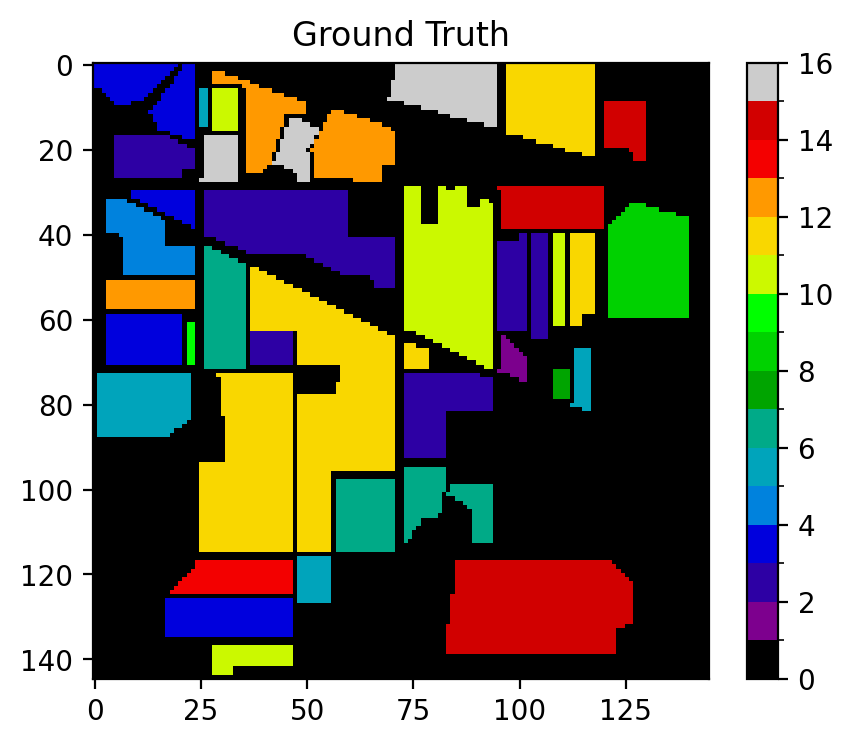

In [227]:
from matplotlib import colors
cmap = pl.get_cmap('nipy_spectral')
# Define discrete boundaries for the values (0 to 16)
bounds = np.arange(min_label, max_label+1, 1)  # Ensures correct mapping of colors
norm = BoundaryNorm(bounds, cmap.N)

fig, axes = pl.subplots(figsize=(5,4))
pl.imshow(labelsMat, cmap=cmap,norm=norm)
pl.colorbar()
pl.title(r"Ground Truth")
pl.show()

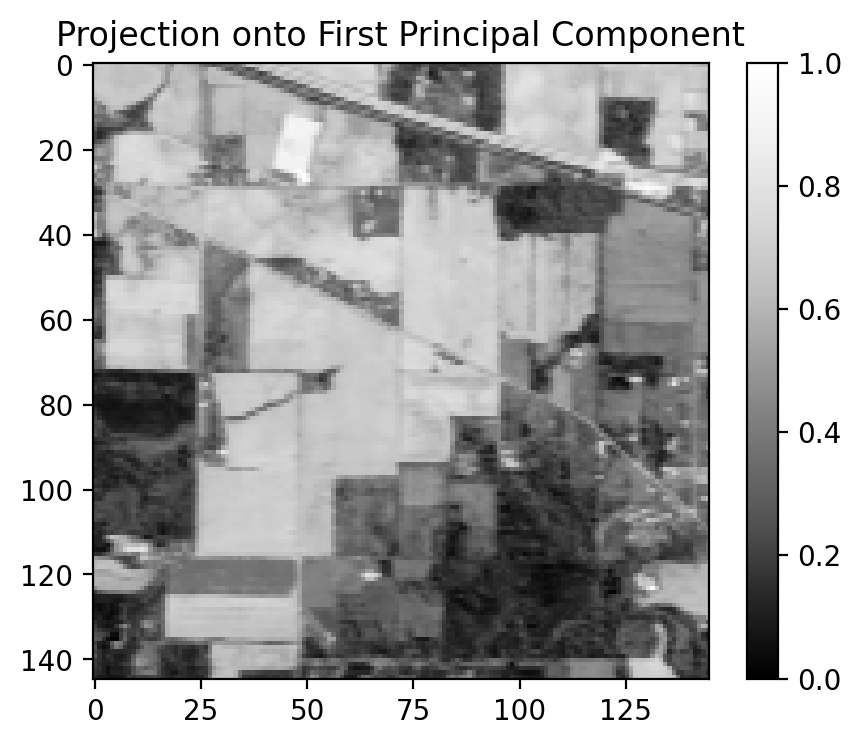

In [134]:
# Reshape into 2D image
img_pca = X_pca.reshape(nY,nX)

# Normalize to range [0,1] 
img_pca = (img_pca - np.min(img_pca))/(np.max(img_pca)-np.min(img_pca))

fig, axes = pl.subplots(figsize=(5,4))
pl.imshow(img_pca, cmap='Greys_r')
pl.colorbar()
pl.title('Projection onto First Principal Component')
pl.show()

### Experiments

We perform experiments to evaluate the impact of the following on the classification accuracy. The dimensionality of the reduced deature set is fixed as 30 following the paper.

    1) S - Number of superpixels
    2) k - Number of neighbors to consider for reconstruction
    3) Reconstruction criterion (Spectral similarity vs Spatial proximity)
    4) Segmentation algorithm (SLIC vs ERS)
    5) T - Number of training samples per class

Experiment 1: Impact of the superpixelization method and the number of superpixels

Set k = 0 (i.e. no reconstruction) and perform dimensionality reduction using S = {10, 30, 50, 60, 70, 80, 90, 100, 110, 120, 140, 175, 200}
and both SLIC and ERS. For each case, perform SVM classification 20 times with randomized training dataset with T = 30 samples per class and calculate the average overall accuracy.

In [135]:
k = 0
T = 30
nComponents = 30
n_SVM_runs = 20

S_array = np.array([1, 3, 5, 10, 20, 30, 40, 50, 75, 100, 150, 200, 300])
S_actual_SLIC = np.zeros(len(S_array),dtype=int)
acc_SLIC = np.zeros(len(S_array),dtype=float)
acc_ERS = np.zeros(len(S_array),dtype=float)

In [139]:
for it, S in enumerate(S_array):
    
    print(f"\nPerforming iteration for S = {S}")
    
    s3pca = S3PCA()
    s3pca.initialize(data3Darr, labelsMat)
    s3pca.segment(S, method="SLIC", **{'sigma':0.0, 'compactness':0.1})
    S_actual_SLIC[it] = s3pca.nSegments
    
    s3pca.superpixelwiseDataMatFromGlobalDataMat()
    s3pca.reconstructSuperpixelwiseDataMat(k, "spectral")
    s3pca.reduceAndAssemble(nComponents)
    
    acc_array = np.zeros(n_SVM_runs)
    
    for j in range(n_SVM_runs):
        s3pca.performClassification(T, random_seed=j)
        acc_array[j] = s3pca.overall_accuracy
        
    acc_SLIC[it] = np.mean(acc_array)
    
    print(f"Accuracy : {np.mean(acc_array)}")


Performing iteration for S = 1
Successfully segmented the image into 1 superpixels.
Accuracy : 0.6571748878923767

Performing iteration for S = 3
Successfully segmented the image into 1 superpixels.
Accuracy : 0.6571748878923767

Performing iteration for S = 5
Successfully segmented the image into 1 superpixels.
Accuracy : 0.6571748878923767

Performing iteration for S = 10
Successfully segmented the image into 4 superpixels.
Accuracy : 0.7430034651447207

Performing iteration for S = 20
Successfully segmented the image into 15 superpixels.
Accuracy : 0.8325315939665716

Performing iteration for S = 30
Successfully segmented the image into 25 superpixels.
Accuracy : 0.8810283326538931

Performing iteration for S = 40
Successfully segmented the image into 30 superpixels.
Accuracy : 0.8795607419486343

Performing iteration for S = 50
Successfully segmented the image into 31 superpixels.
Accuracy : 0.9071443130860171

Performing iteration for S = 75
Successfully segmented the image into 

In [140]:
exp1_slic = pd.DataFrame({"S": S_actual_SLIC,"OA": acc_SLIC})
exp1_slic_unique = exp1_slic.groupby("S", as_index=False).max()
exp1_slic_unique.to_csv("Experiments/Exp1_SLIC.csv", index=False)

In [142]:
for it, S in enumerate(S_array):
    
    print(f"\nPerforming iteration for S = {S}")
    
    s3pca = S3PCA()
    s3pca.initialize(data3Darr, labelsMat)
    s3pca.segment(S, method="ERS")
    
    s3pca.superpixelwiseDataMatFromGlobalDataMat()
    s3pca.reconstructSuperpixelwiseDataMat(k, "spectral")
    s3pca.reduceAndAssemble(nComponents)
    
    acc_array = np.zeros(n_SVM_runs)
    
    for j in range(n_SVM_runs):
        s3pca.performClassification(T, random_seed=j)
        acc_array[j] = s3pca.overall_accuracy
        
    acc_ERS[it] = np.mean(acc_array)
    
    print(f"Accuracy : {np.mean(acc_array)}")


Performing iteration for S = 1
Successfully segmented the image into 1 superpixels.
Accuracy : 0.6571748878923767

Performing iteration for S = 3
Successfully segmented the image into 3 superpixels.
Accuracy : 0.7277262535670608

Performing iteration for S = 5
Successfully segmented the image into 5 superpixels.
Accuracy : 0.7995006114961272

Performing iteration for S = 10
Successfully segmented the image into 10 superpixels.
Accuracy : 0.8637128006522625

Performing iteration for S = 20
Successfully segmented the image into 20 superpixels.
Accuracy : 0.8745617611088464

Performing iteration for S = 30
Successfully segmented the image into 30 superpixels.
Accuracy : 0.9086526701997553

Performing iteration for S = 40
Successfully segmented the image into 40 superpixels.
Accuracy : 0.9220342437831228

Performing iteration for S = 50
Successfully segmented the image into 50 superpixels.
Accuracy : 0.9064563799429273

Performing iteration for S = 75
Successfully segmented the image into

In [143]:
exp1_ers = pd.DataFrame({"S": S_array,"OA": acc_ERS})
exp1_ers.to_csv("Experiments/Exp1_ERS.csv", index=False)

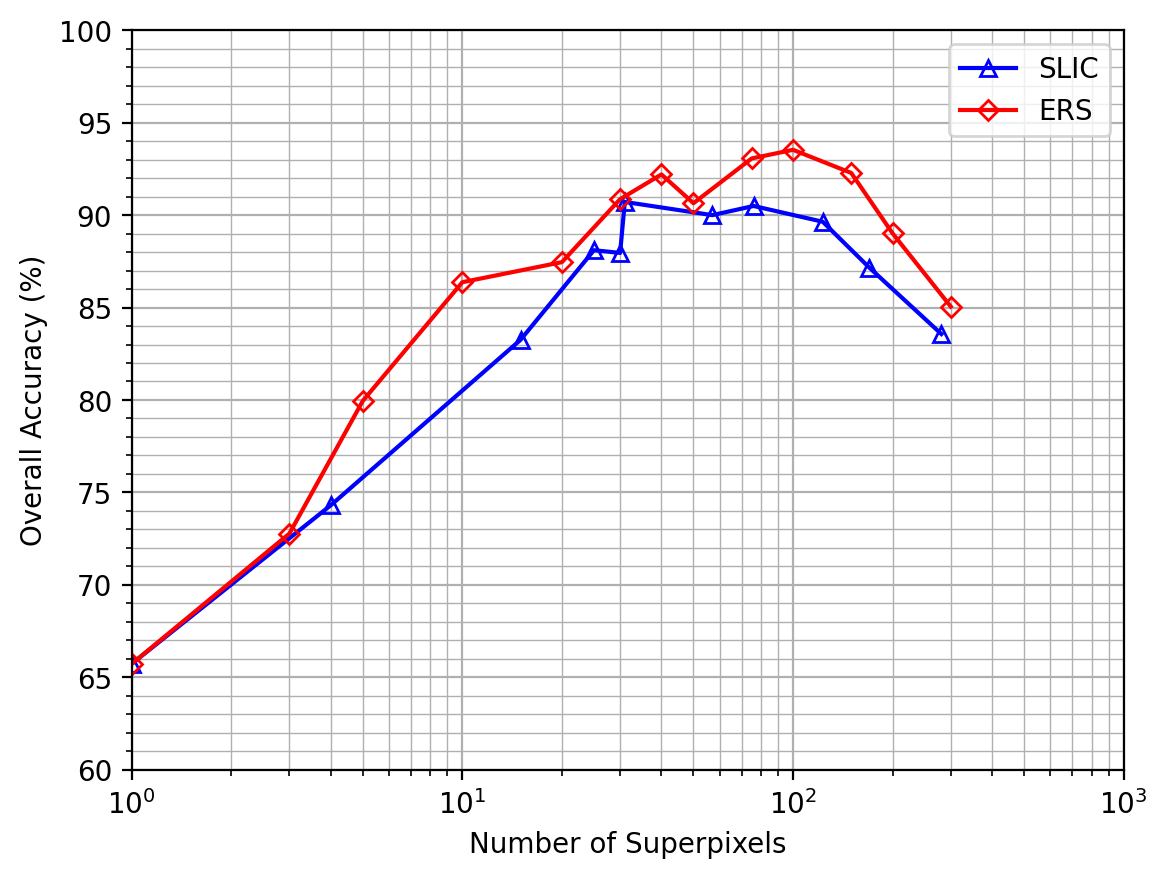

In [144]:
Exp1_SLIC_data = pd.read_csv("Experiments/Exp1_SLIC.csv")
S_SLIC = Exp1_SLIC_data["S"]
OA_SLIC = Exp1_SLIC_data["OA"]*100

Exp1_ERS_data = pd.read_csv("Experiments/Exp1_ERS.csv")
S_ERS = Exp1_ERS_data["S"]
OA_ERS = Exp1_ERS_data["OA"]*100

pl.plot(S_SLIC, OA_SLIC, marker = '^', color = 'b', markerfacecolor = 'none', label = 'SLIC')
pl.plot(S_ERS, OA_ERS, marker = 'D', markersize = 5, markerfacecolor = 'none', color = 'r', label = 'ERS')
pl.xlabel('Number of Superpixels')
pl.ylabel('Overall Accuracy (%)')
pl.xscale('log')
pl.xlim([1, 1000])
pl.ylim([60, 100])
pl.legend()
pl.grid()
pl.minorticks_on()
pl.grid(which='minor', linestyle='-', linewidth=0.5)
pl.show()

We can see that S3-PCA performs better when ERS is used instead of SLIC for the segmentation step, i.e. ERS produces more homogenous and compact superpixels when compared to SLIC, which leads to a better low-dimensional representation of the data using S3-PCA.

Since ERS outperforms SLIC, we will use only ERS for the remaining experiments.

Experiment 2: Impact of number of neighbors chosen for reconstruction and the reconstruction criterion

Perform segmentation with S = 100 (optimal value from experiment 1) and perform dimensionality reconstruction using k = {1, 3, 5, 7, 9, 11, 13, 15, 17, 19} using spectral similarity and spatial proximity as criterion. Reduce the dimensionality, and then perform SVM classification 20 times with randomized training dataset with T = 30 samples per class and calculate the average overall accuracy.

In [145]:
T = 30
nComponents = 30
n_SVM_runs = 20
S = 100

k_array = np.array([0, 5, 7, 9, 11, 13, 15, 17, 19])

acc_spectral = np.zeros(len(k_array),dtype=float)
acc_spatial = np.zeros(len(k_array),dtype=float)

In [146]:
s3pca = S3PCA()
s3pca.initialize(data3Darr, labelsMat)
s3pca.segment(S, method="ERS")
s3pca.superpixelwiseDataMatFromGlobalDataMat()

for it, k in enumerate(k_array):
    
    print(f"\nPerforming iteration for k = {k}")
    s3pca.reconstructSuperpixelwiseDataMat(k, "spectral")
    s3pca.reduceAndAssemble(nComponents)

    acc_array = np.zeros(n_SVM_runs)
    
    for j in range(n_SVM_runs):
        s3pca.performClassification(T, random_seed=j)
        acc_array[j] = s3pca.overall_accuracy
        
    acc_spectral[it] = np.mean(acc_array)
    
    print(f"Accuracy : {np.mean(acc_array)}")

Successfully segmented the image into 100 superpixels.

Performing iteration for k = 0
Accuracy : 0.935344476151651

Performing iteration for k = 5
Accuracy : 0.9396351406441094

Performing iteration for k = 7
Accuracy : 0.9387484712596821

Performing iteration for k = 9
Accuracy : 0.9363177741540971

Performing iteration for k = 11
Accuracy : 0.9376324908275582

Performing iteration for k = 13
Accuracy : 0.9447003668976764

Performing iteration for k = 15
Accuracy : 0.9377700774561764

Performing iteration for k = 17
Accuracy : 0.9406848756624541

Performing iteration for k = 19
Accuracy : 0.939089889930697


In [147]:
exp2_spectral = pd.DataFrame({"k": k_array,"OA": acc_spectral})
exp2_spectral.to_csv("Experiments/Exp2_spectral.csv", index=False)

In [148]:
for it, k in enumerate(k_array):
    
    print(f"\nPerforming iteration for k = {k}")
    s3pca.reconstructSuperpixelwiseDataMat(k, "spatial")
    s3pca.reduceAndAssemble(nComponents)

    acc_array = np.zeros(n_SVM_runs)
    
    for j in range(n_SVM_runs):
        s3pca.performClassification(T, random_seed=j)
        acc_array[j] = s3pca.overall_accuracy
        
    acc_spatial[it] = np.mean(acc_array)
    
    print(f"Accuracy : {np.mean(acc_array)}")


Performing iteration for k = 0
Accuracy : 0.935344476151651

Performing iteration for k = 5
Accuracy : 0.9376885446392171

Performing iteration for k = 7
Accuracy : 0.9403128821850796

Performing iteration for k = 9
Accuracy : 0.933143090093763

Performing iteration for k = 11
Accuracy : 0.9378057480635956

Performing iteration for k = 13
Accuracy : 0.943110476966979

Performing iteration for k = 15
Accuracy : 0.9414696290256828

Performing iteration for k = 17
Accuracy : 0.9429728903383611

Performing iteration for k = 19
Accuracy : 0.937851610273135


In [149]:
exp2_spatial = pd.DataFrame({"k": k_array,"OA": acc_spatial})
exp2_spatial.to_csv("Experiments/Exp2_spatial.csv", index=False)

We see that the criterion for reconstruction, namely "spectral similarity" or "spatial proximity" have very little impact on the classification accuracy. For both criteria, k = 13 gives the best results although the improvement due to reconstruction is minimal.

Experiment 3: Comparison between S3-PCA (with and without superpixelwise reconstruction) and SuperPCA

Set k = 13 for S3-PCA and perform dimensionality reduction using S = {10, 30, 50, 60, 70, 80, 90, 100, 110, 120, 140, 175, 200}
and both SuperPCA and S3-PCA. For each case, perform SVM classification 20 times with randomized training dataset with T = 30 samples per class and calculate the average overall accuracy.


In [150]:
k = 13
T = 30
nComponents = 30
n_SVM_runs = 20

S_array = np.array([1, 3, 5, 10, 20, 30, 40, 50, 75, 100, 150, 200, 300])
acc_s3pca = np.zeros(len(S_array),dtype=float)
acc_superpca = np.zeros(len(S_array),dtype=float)

In [151]:
for it, S in enumerate(S_array):
    
    print(f"\nPerforming iteration for S = {S}")
    
    s3pca = S3PCA()
    s3pca.initialize(data3Darr, labelsMat)
    s3pca.segment(S, method="ERS")
    
    s3pca.superpixelwiseDataMatFromGlobalDataMat()
    s3pca.reconstructSuperpixelwiseDataMat(k, "spectral")
    s3pca.reduceAndAssemble(nComponents)
    
    acc_array = np.zeros(n_SVM_runs)
    
    for j in range(n_SVM_runs):
        s3pca.performClassification(T, random_seed=j)
        acc_array[j] = s3pca.overall_accuracy
        
    acc_s3pca[it] = np.mean(acc_array)
    
    print(f"Accuracy : {np.mean(acc_array)}")


Performing iteration for S = 1
Successfully segmented the image into 1 superpixels.
Accuracy : 0.8037759885854057

Performing iteration for S = 3
Successfully segmented the image into 3 superpixels.
Accuracy : 0.8357113738279658

Performing iteration for S = 5
Successfully segmented the image into 5 superpixels.
Accuracy : 0.8826131267835302

Performing iteration for S = 10
Successfully segmented the image into 10 superpixels.
Accuracy : 0.9098298002445985

Performing iteration for S = 20
Successfully segmented the image into 20 superpixels.
Accuracy : 0.9119547492865878

Performing iteration for S = 30
Successfully segmented the image into 30 superpixels.
Accuracy : 0.9298053403995109

Performing iteration for S = 40
Successfully segmented the image into 40 superpixels.
Accuracy : 0.9383509987770078

Performing iteration for S = 50
Successfully segmented the image into 50 superpixels.
Accuracy : 0.9276192417448023

Performing iteration for S = 75
Successfully segmented the image into

In [152]:
exp3_s3pca = pd.DataFrame({"S": S_array,"OA": acc_s3pca})
exp3_s3pca.to_csv("Experiments/Exp3_s3pca.csv", index=False)

In [155]:
for it, S in enumerate(S_array):
    
    print(f"\nPerforming iteration for S = {S}")
    
    superpca = SuperPCA()
    superpca.initialize(data3Darr, labelsMat)
    superpca.segment(S, method="ERS")
    
    superpca.superpixelwiseDataMatFromGlobalDataMat()
    superpca.reduceAndAssemble(nComponents)
    
    acc_array = np.zeros(n_SVM_runs)
    
    for j in range(n_SVM_runs):
        superpca.performClassification(T, random_seed=j)
        acc_array[j] = superpca.overall_accuracy
        
    acc_superpca[it] = np.mean(acc_array)
    
    print(f"Accuracy : {np.mean(acc_array)}")


Performing iteration for S = 1
Successfully segmented the image into 1 superpixels.
Accuracy : 0.6572309417040358

Performing iteration for S = 3
Successfully segmented the image into 3 superpixels.
Accuracy : 0.7243681206685689

Performing iteration for S = 5
Successfully segmented the image into 5 superpixels.
Accuracy : 0.7992050550346514

Performing iteration for S = 10
Successfully segmented the image into 10 superpixels.
Accuracy : 0.864930697105585

Performing iteration for S = 20
Successfully segmented the image into 20 superpixels.
Accuracy : 0.8739859355890746

Performing iteration for S = 30
Successfully segmented the image into 30 superpixels.
Accuracy : 0.9049836934366082

Performing iteration for S = 40
Successfully segmented the image into 40 superpixels.
Accuracy : 0.920199755401549

Performing iteration for S = 50
Successfully segmented the image into 50 superpixels.
Accuracy : 0.90485629841011

Performing iteration for S = 75
Successfully segmented the image into 75 

In [156]:
exp3_superpca = pd.DataFrame({"S": S_array,"OA": acc_superpca})
exp3_superpca.to_csv("Experiments/Exp3_superpca.csv", index=False)

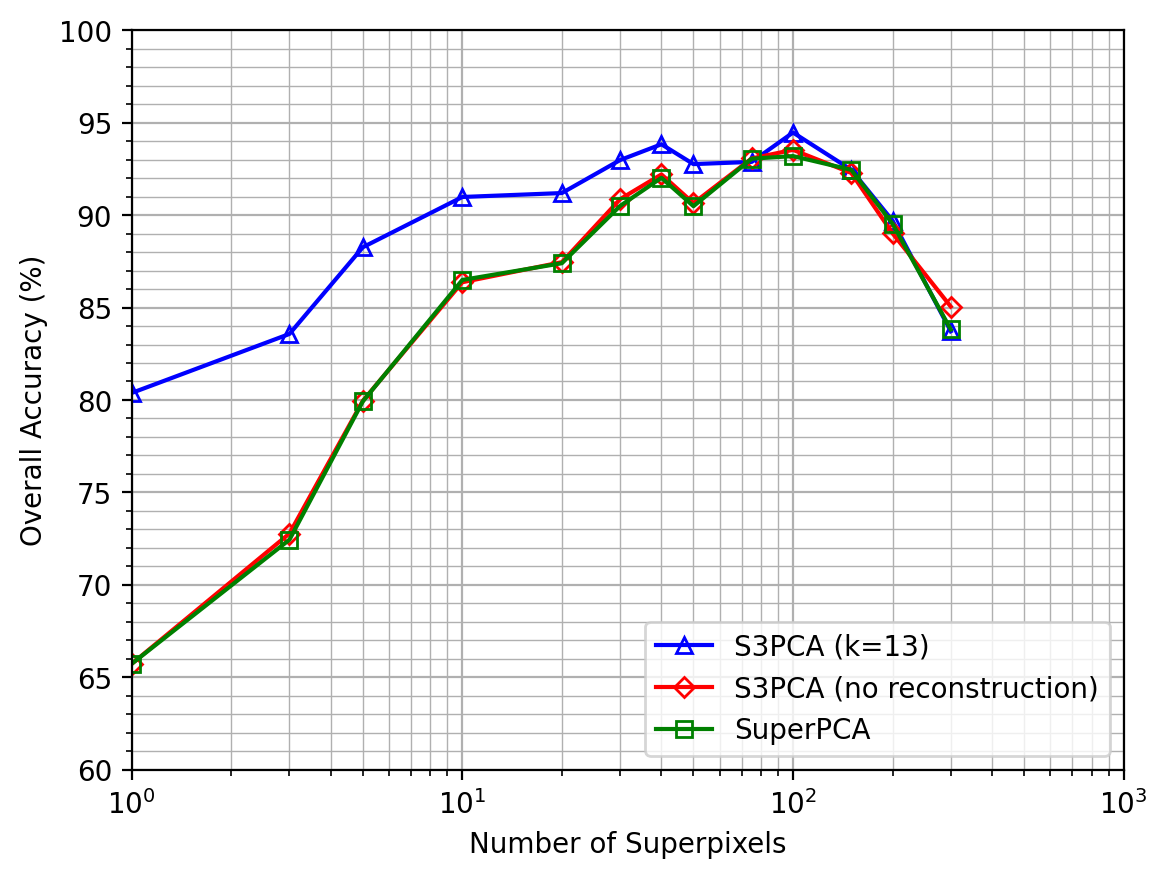

In [159]:
Exp1_ERS_data = pd.read_csv("Experiments/Exp1_ERS.csv")
S_ERS = Exp1_ERS_data["S"]
OA_ERS = Exp1_ERS_data["OA"]*100

Exp3_S3PCA_data = pd.read_csv("Experiments/Exp3_s3pca.csv")
S_S3PCA = Exp3_S3PCA_data["S"]
OA_S3PCA = Exp3_S3PCA_data["OA"]*100

Exp3_SuperPCA_data = pd.read_csv("Experiments/Exp3_superpca.csv")
S_SuperPCA = Exp3_SuperPCA_data["S"]
OA_SuperPCA = Exp3_SuperPCA_data["OA"]*100

pl.plot(S_S3PCA, OA_S3PCA, marker = '^', color = 'b', markerfacecolor = 'none', label = 'S3PCA (k=13)')
pl.plot(S_ERS, OA_ERS, marker = 'D', markersize = 5, markerfacecolor = 'none', color = 'r', label = 'S3PCA (no reconstruction)')
pl.plot(S_SuperPCA, OA_SuperPCA, marker = 's', color = 'green', markerfacecolor = 'none', label = 'SuperPCA')

pl.xlabel('Number of Superpixels')
pl.ylabel('Overall Accuracy (%)')
pl.xscale('log')
pl.xlim([1, 1000])
pl.ylim([60, 100])
pl.legend()
pl.grid()
pl.minorticks_on()
pl.grid(which='minor', linestyle='-', linewidth=0.5)
pl.show()

Experiment 4:

We compare the performance of PCA, SuperPCA and S3PCA for different number of training samples. S = 100 and k = 13 are the hyperparameters used based on results of previous experiments.

In [161]:
k = 13
S = 100
T_array = np.array([5, 10, 20, 30, 40, 50, 60])
nComponents = 30
n_SVM_runs = 20


exp4_acc_s3pca = np.zeros(len(T_array),dtype=float)
exp4_acc_superpca = np.zeros(len(T_array),dtype=float)
exp4_acc_pca = np.zeros(len(T_array),dtype=float)

In [166]:
# S3PCA
s3pca = S3PCA()
s3pca.initialize(data3Darr, labelsMat)
s3pca.segment(S, method="ERS")
s3pca.superpixelwiseDataMatFromGlobalDataMat()
s3pca.reconstructSuperpixelwiseDataMat(k, "spectral")
s3pca.reduceAndAssemble(nComponents)

for it, T in enumerate(T_array):
    
    print(f"\nPerforming iteration for T = {T}")
    
    acc_array = np.zeros(n_SVM_runs)
    
    for j in range(n_SVM_runs):
        s3pca.performClassification(T, random_seed=j)
        acc_array[j] = s3pca.overall_accuracy
        
    exp4_acc_s3pca[it] = np.mean(acc_array)
    
    print(f"Accuracy : {np.mean(acc_array)}")

Successfully segmented the image into 100 superpixels.

Performing iteration for T = 5
Accuracy : 0.641464254105615

Performing iteration for T = 10
Accuracy : 0.8134056893646546

Performing iteration for T = 20
Accuracy : 0.9106837606837608

Performing iteration for T = 30
Accuracy : 0.9447003668976764

Performing iteration for T = 40
Accuracy : 0.957968394959719

Performing iteration for T = 50
Accuracy : 0.9697833821682714

Performing iteration for T = 60
Accuracy : 0.9717200084781688


In [167]:
exp4_s3pca = pd.DataFrame({"T": T_array,"OA": exp4_acc_s3pca})
exp4_s3pca.to_csv("Experiments/Exp4_s3pca.csv", index=False)

In [168]:
# SuperPCA
superpca = SuperPCA()
superpca.initialize(data3Darr, labelsMat)
superpca.segment(S, method="ERS")
superpca.superpixelwiseDataMatFromGlobalDataMat()
superpca.reduceAndAssemble(nComponents)

for it, T in enumerate(T_array):
    
    print(f"\nPerforming iteration for T = {T}")
    
    acc_array = np.zeros(n_SVM_runs)
    
    for j in range(n_SVM_runs):
        superpca.performClassification(T, random_seed=j)
        acc_array[j] = superpca.overall_accuracy
        
    exp4_acc_superpca[it] = np.mean(acc_array)
    
    print(f"Accuracy : {np.mean(acc_array)}")

Successfully segmented the image into 100 superpixels.

Performing iteration for T = 5
Accuracy : 0.6313452650211427

Performing iteration for T = 10
Accuracy : 0.8027852116166121

Performing iteration for T = 20
Accuracy : 0.8946153846153846

Performing iteration for T = 30
Accuracy : 0.9319557684467998

Performing iteration for T = 40
Accuracy : 0.9495920264408181

Performing iteration for T = 50
Accuracy : 0.9613331938049395

Performing iteration for T = 60
Accuracy : 0.9640790589232724


In [169]:
exp4_superpca = pd.DataFrame({"T": T_array,"OA": exp4_acc_superpca})
exp4_superpca.to_csv("Experiments/Exp4_superpca.csv", index=False)

In [172]:
# PCA
pca_ = PCA()
pca_.initialize(data3Darr, labelsMat)
pca_.reduceAndAssemble(nComponents)

for it, T in enumerate(T_array):
    
    print(f"\nPerforming iteration for T = {T}")
    
    acc_array = np.zeros(n_SVM_runs)
    
    for j in range(n_SVM_runs):
        pca_.performClassification(T, random_seed=j)
        acc_array[j] = pca_.overall_accuracy
        
    exp4_acc_pca[it] = np.mean(acc_array)
    
    print(f"Accuracy : {np.mean(acc_array)}")


Performing iteration for T = 5
Accuracy : 0.4468826826629953

Performing iteration for T = 10
Accuracy : 0.5305778570720588

Performing iteration for T = 20
Accuracy : 0.6119959778783308

Performing iteration for T = 30
Accuracy : 0.6572309417040358

Performing iteration for T = 40
Accuracy : 0.683252427184466

Performing iteration for T = 50
Accuracy : 0.7051852239430723

Performing iteration for T = 60
Accuracy : 0.7158594743535397


In [173]:
exp4_pca = pd.DataFrame({"T": T_array,"OA": exp4_acc_pca})
exp4_pca.to_csv("Experiments/Exp4_pca.csv", index=False)

In [182]:
# Raw data
exp4_acc_raw = np.zeros(len(T_array),dtype=float)

raw = RawData()
raw.initialize(data3Darr, labelsMat)

for it, T in enumerate(T_array):
    
    print(f"\nPerforming iteration for T = {T}")
    
    acc_array = np.zeros(n_SVM_runs)
    
    for j in range(n_SVM_runs):
        raw.performClassification(T, random_seed=j)
        acc_array[j] = raw.overall_accuracy
        
    exp4_acc_raw[it] = np.mean(acc_array)
    
    print(f"Accuracy : {np.mean(acc_array)}")


Performing iteration for T = 5
Accuracy : 0.4482151637329138

Performing iteration for T = 10
Accuracy : 0.5358558826444644

Performing iteration for T = 20
Accuracy : 0.6262393162393162

Performing iteration for T = 30
Accuracy : 0.6723298002445984

Performing iteration for T = 40
Accuracy : 0.6998605659987606

Performing iteration for T = 50
Accuracy : 0.7244453746337379

Performing iteration for T = 60
Accuracy : 0.7443408223823654


In [183]:
exp4_raw = pd.DataFrame({"T": T_array,"OA": exp4_acc_raw})
exp4_raw.to_csv("Experiments/Exp4_raw.csv", index=False)

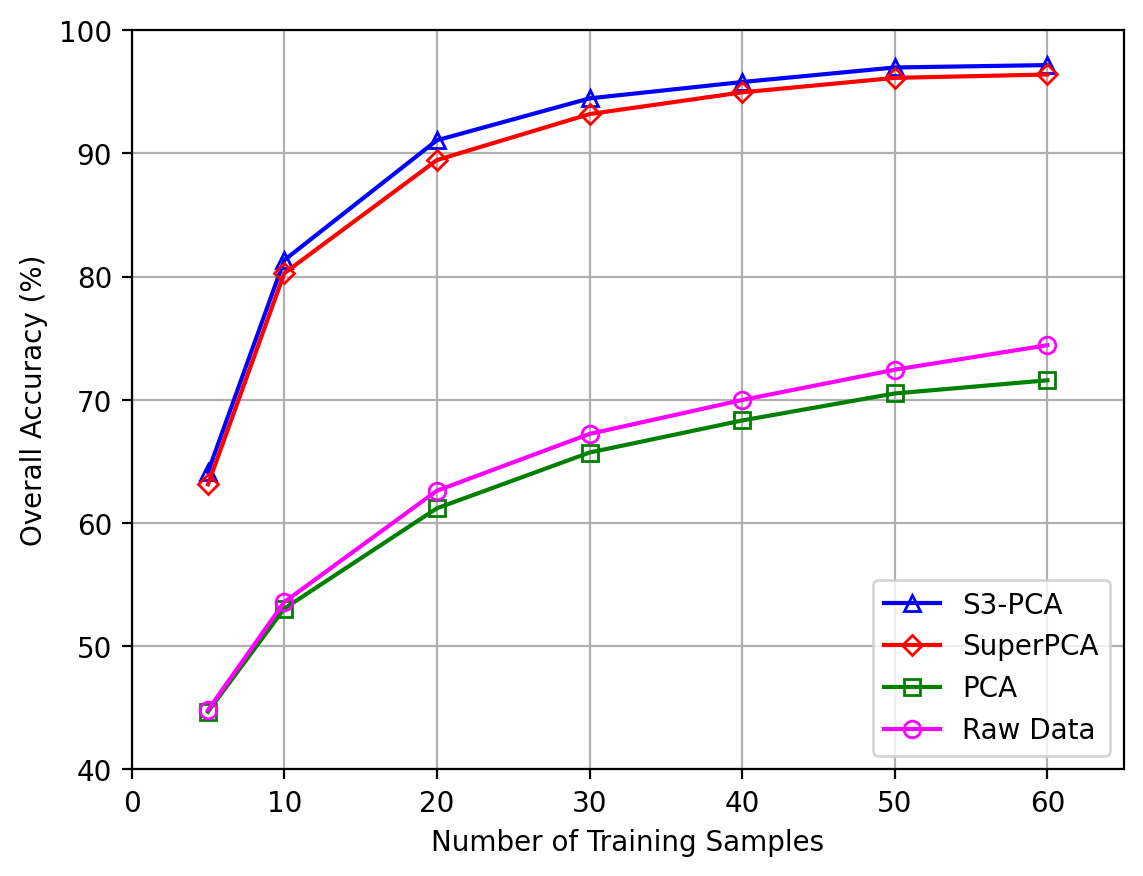

In [189]:
Exp4_S3PCA_data = pd.read_csv("Experiments/Exp4_s3pca.csv")
Exp4_T_S3PCA = Exp4_S3PCA_data["T"]
Exp4_OA_S3PCA = Exp4_S3PCA_data["OA"]*100

Exp4_SuperPCA_data = pd.read_csv("Experiments/Exp4_superpca.csv")
Exp4_T_SuperPCA = Exp4_SuperPCA_data["T"]
Exp4_OA_SuperPCA = Exp4_SuperPCA_data["OA"]*100

Exp4_PCA_data = pd.read_csv("Experiments/Exp4_pca.csv")
Exp4_T_PCA = Exp4_PCA_data["T"]
Exp4_OA_PCA = Exp4_PCA_data["OA"]*100

Exp4_raw_data = pd.read_csv("Experiments/Exp4_raw.csv")
Exp4_T_raw = Exp4_raw_data["T"]
Exp4_OA_raw = Exp4_raw_data["OA"]*100

pl.plot(Exp4_T_S3PCA, Exp4_OA_S3PCA, marker = '^', color = 'b', markerfacecolor = 'none', label = 'S3-PCA')
pl.plot(Exp4_T_SuperPCA, Exp4_OA_SuperPCA, marker = 'D', markersize = 5, markerfacecolor = 'none', color = 'r', label = 'SuperPCA')
pl.plot(Exp4_T_PCA, Exp4_OA_PCA, marker = 's', color = 'green', markerfacecolor = 'none', label = 'PCA')
pl.plot(Exp4_T_raw, Exp4_OA_raw, marker = '.', color = 'magenta', markerfacecolor = 'none', markersize = 12, label = 'Raw Data')


pl.xlabel('Number of Training Samples')
pl.ylabel('Overall Accuracy (%)')
pl.xlim([0, 65])
pl.ylim([40, 100])
pl.legend()
pl.grid()
pl.show()

Classification Maps

In [191]:
k = 13
S = 100
T = 30
n_SVM_runs = 20
from scipy.stats import mode

In [192]:
predicted_labels_array_raw = np.zeros((n_SVM_runs, data3Darr.shape[0], data3Darr.shape[1]))

raw = RawData()
raw.initialize(data3Darr, labelsMat)

for j in range(n_SVM_runs):
        raw.performClassification(T, random_seed=j)
        predicted_labels_array_raw[j] = raw.labels2D_array_predicted

predicted_labels_raw, _ = mode(predicted_labels_array_raw, axis=0, keepdims=False)   

In [197]:
predicted_labels_array_pca = np.zeros((n_SVM_runs, data3Darr.shape[0], data3Darr.shape[1]))

pca_ = PCA()
pca_.initialize(data3Darr, labelsMat)
pca_.reduceAndAssemble(nComponents)

for j in range(n_SVM_runs):
        pca_.performClassification(T, random_seed=j)
        predicted_labels_array_pca[j] = pca_.labels2D_array_predicted

predicted_labels_pca, _ = mode(predicted_labels_array_pca, axis=0, keepdims=False)

In [198]:
predicted_labels_array_superpca = np.zeros((n_SVM_runs, data3Darr.shape[0], data3Darr.shape[1]))

superpca = SuperPCA()
superpca.initialize(data3Darr, labelsMat)
superpca.segment(S, method="ERS")
superpca.superpixelwiseDataMatFromGlobalDataMat()
superpca.reduceAndAssemble(nComponents)

for j in range(n_SVM_runs):
        superpca.performClassification(T, random_seed=j)
        predicted_labels_array_superpca[j] = superpca.labels2D_array_predicted

predicted_labels_superpca, _ = mode(predicted_labels_array_superpca, axis=0, keepdims=False)

Successfully segmented the image into 100 superpixels.


In [199]:
predicted_labels_array_s3pca = np.zeros((n_SVM_runs, data3Darr.shape[0], data3Darr.shape[1]))

s3pca = S3PCA()
s3pca.initialize(data3Darr, labelsMat)
s3pca.segment(S, method="ERS")
s3pca.superpixelwiseDataMatFromGlobalDataMat()
s3pca.reconstructSuperpixelwiseDataMat(k, "spectral")
s3pca.reduceAndAssemble(nComponents)

for j in range(n_SVM_runs):
        s3pca.performClassification(T, random_seed=j)
        predicted_labels_array_s3pca[j] = s3pca.labels2D_array_predicted

predicted_labels_s3pca, _ = mode(predicted_labels_array_s3pca, axis=0, keepdims=False)

Successfully segmented the image into 100 superpixels.


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.037975464883877076..1.0000000000000007].


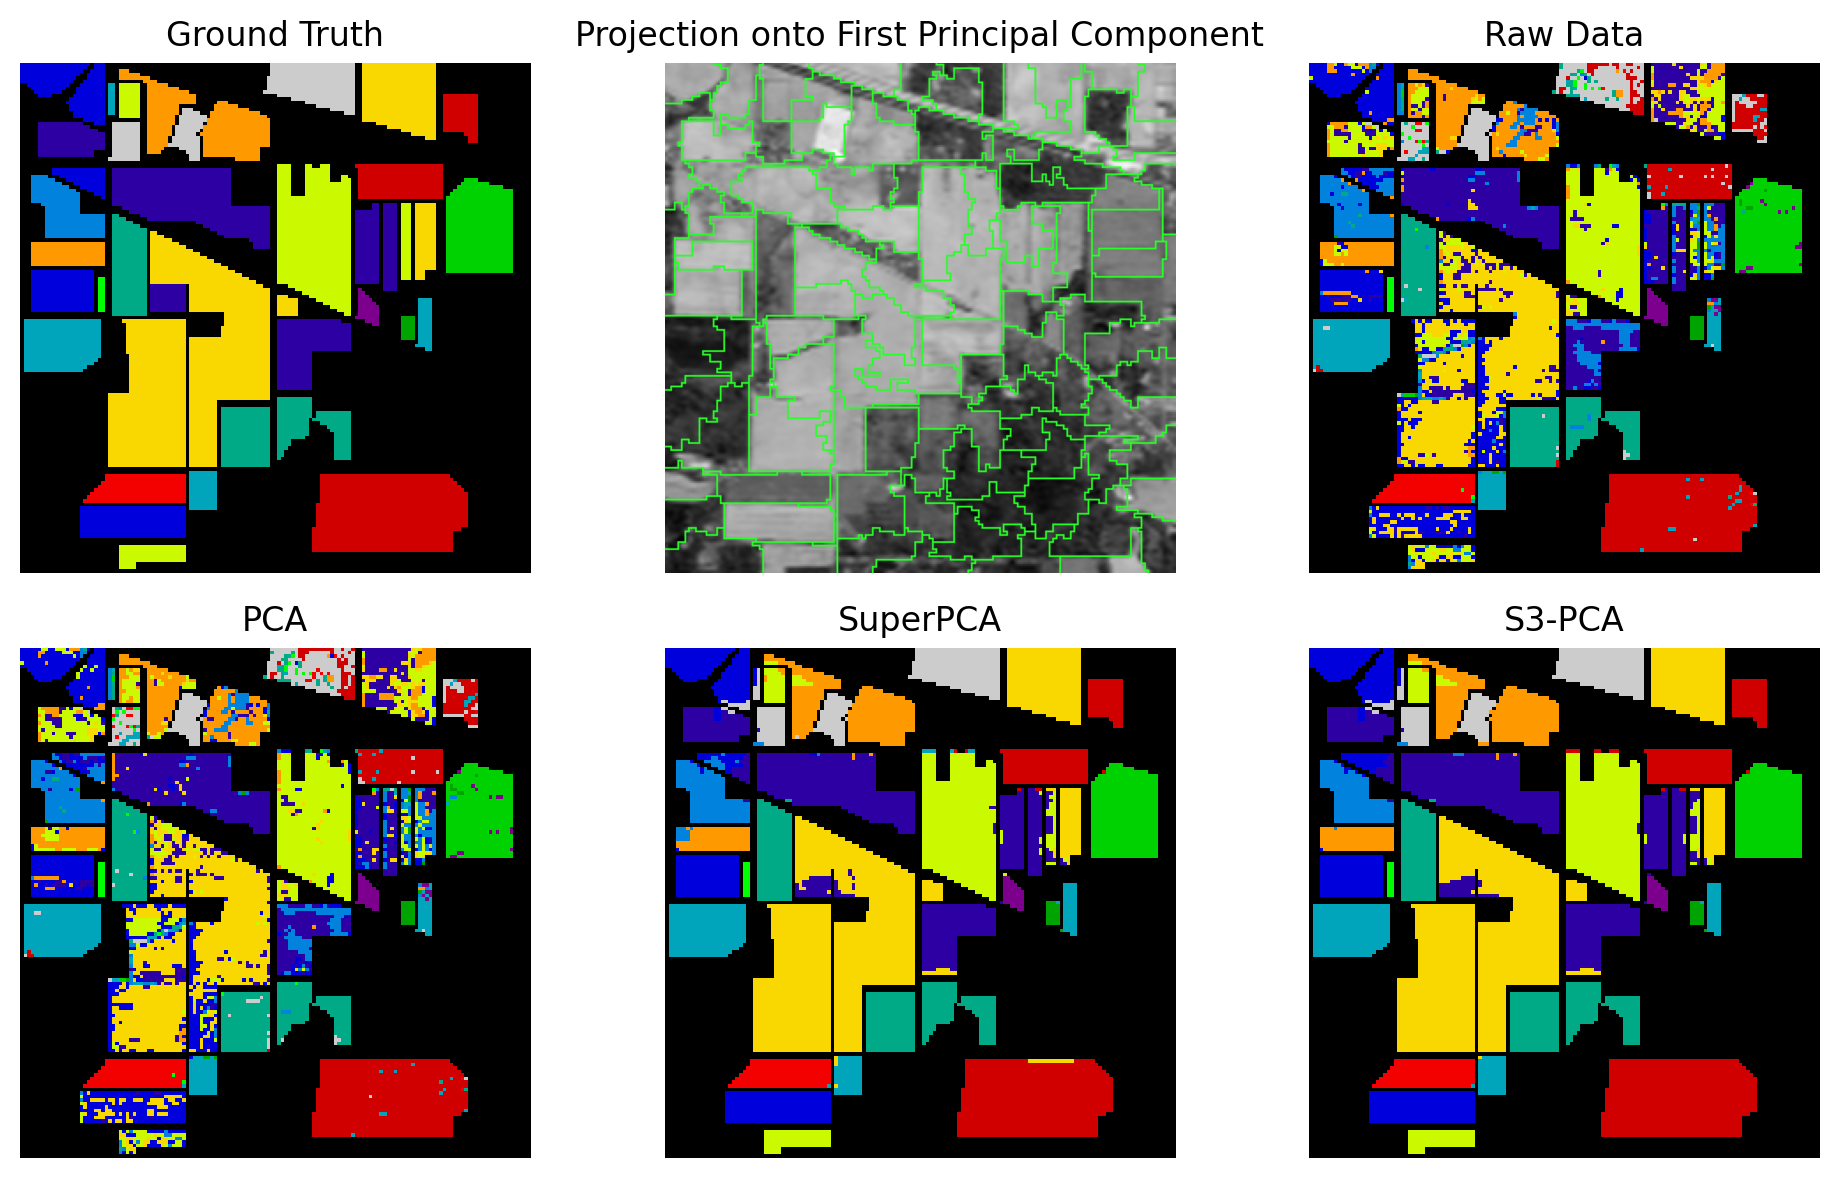

In [228]:
fig, axs = pl.subplots(2, 3, figsize=(10, 6))

segments = s3pca.segments
from skimage.segmentation import mark_boundaries

im1 = axs[0,0].imshow(labelsMat, cmap=cmap, norm=norm)
axs[0,0].axis('off')
axs[0,0].set_title("Ground Truth")

# Raw Data Prediction
im2 = axs[0,2].imshow(predicted_labels_raw, cmap=cmap, norm=norm)
axs[0,2].axis('off')
axs[0,2].set_title("Raw Data")

# PCA Prediction
im3 = axs[1,0].imshow(predicted_labels_pca, cmap=cmap, norm=norm)
axs[1,0].axis('off')
axs[1,0].set_title("PCA")

# Raw Data Prediction
im4 = axs[1,1].imshow(predicted_labels_superpca, cmap=cmap, norm=norm)
axs[1,1].axis('off')
axs[1,1].set_title("SuperPCA")

im5 = axs[1,2].imshow(predicted_labels_s3pca, cmap=cmap, norm=norm)
axs[1,2].axis('off')
axs[1,2].set_title("S3-PCA")

im6 = axs[0,1].imshow(mark_boundaries(img_pca, segments,color=(0.15, 1.0, 0.15),mode='subpixel'),cmap='Greys_r')
axs[0,1].axis('off')
axs[0,1].set_title("Projection onto First Principal Component")


pl.tight_layout()
pl.show()